# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Muhammad Azka Ananta Khairon | 5054251004 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [28]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

In [4]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.

data = pd.read_csv("/content/bankruptcy.csv")
print("Jumlah baris dan kolom:", data.shape)
data.head()

Jumlah baris dan kolom: (6819, 96)


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [6]:
print("Baris duplikat :",(data.duplicated().sum()))
print("Jumlah baris kosong:")
data.isna().sum()[data.isna().sum()>0]

Baris duplikat : 0
Jumlah baris kosong:


,0


In [7]:
stats = data.describe().round(2).T
stats['mode'] = data.mode().iloc[0].values

kolom_order = ['count', 'mean', '50%', 'mode', 'std', 'min', '25%', '75%', 'max']
stats = stats[kolom_order].rename(columns={'50%': 'median'})

print(stats)

                                                     count  mean  median  \
Bankrupt?                                           6819.0  0.03    0.00   
 ROA(C) before interest and depreciation before...  6819.0  0.51    0.50   
 ROA(A) before interest and % after tax             6819.0  0.56    0.56   
 ROA(B) before interest and depreciation after tax  6819.0  0.55    0.55   
 Operating Gross Margin                             6819.0  0.61    0.61   
...                                                    ...   ...     ...   
 Liability to Equity                                6819.0  0.28    0.28   
 Degree of Financial Leverage (DFL)                 6819.0  0.03    0.03   
 Interest Coverage Ratio (Interest expense to E...  6819.0  0.57    0.57   
 Net Income Flag                                    6819.0  1.00    1.00   
 Equity to Liability                                6819.0  0.05    0.03   

                                                        mode   std  min   25%  \
Bankru

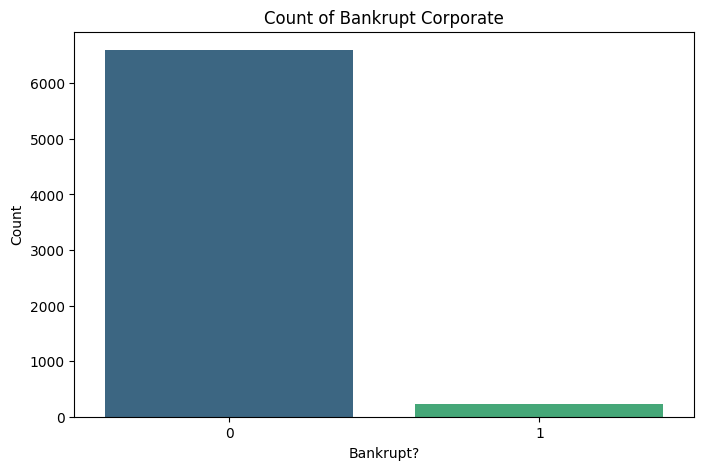

In [8]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

plt.figure(figsize=(8, 5))
sns.countplot(x='Bankrupt?', hue='Bankrupt?', data=data, palette='viridis', legend=False)
plt.title('Count of Bankrupt Corporate')
plt.xlabel('Bankrupt?')
plt.ylabel('Count')
plt.show()

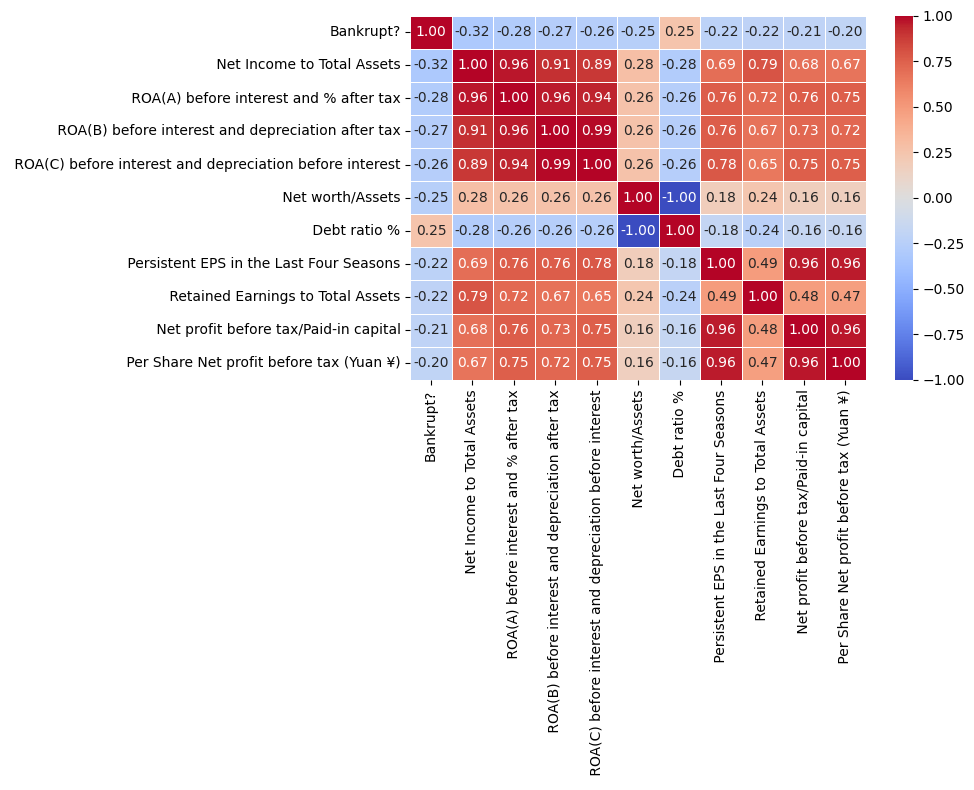

In [9]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.

# correlations heatmap khusus variabel fokus peneitian terhadap target

# pairplot untuk melihat pola pemisahan target di kombinasi antar variabel

target_col = 'Bankrupt?'  # ganti dengan nama kolom targetmu
top_features = (data.corr()[target_col].abs().sort_values(ascending=False).head(11).index)

top_corr_matrix = data[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    top_corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)

plt.tight_layout()
plt.show()

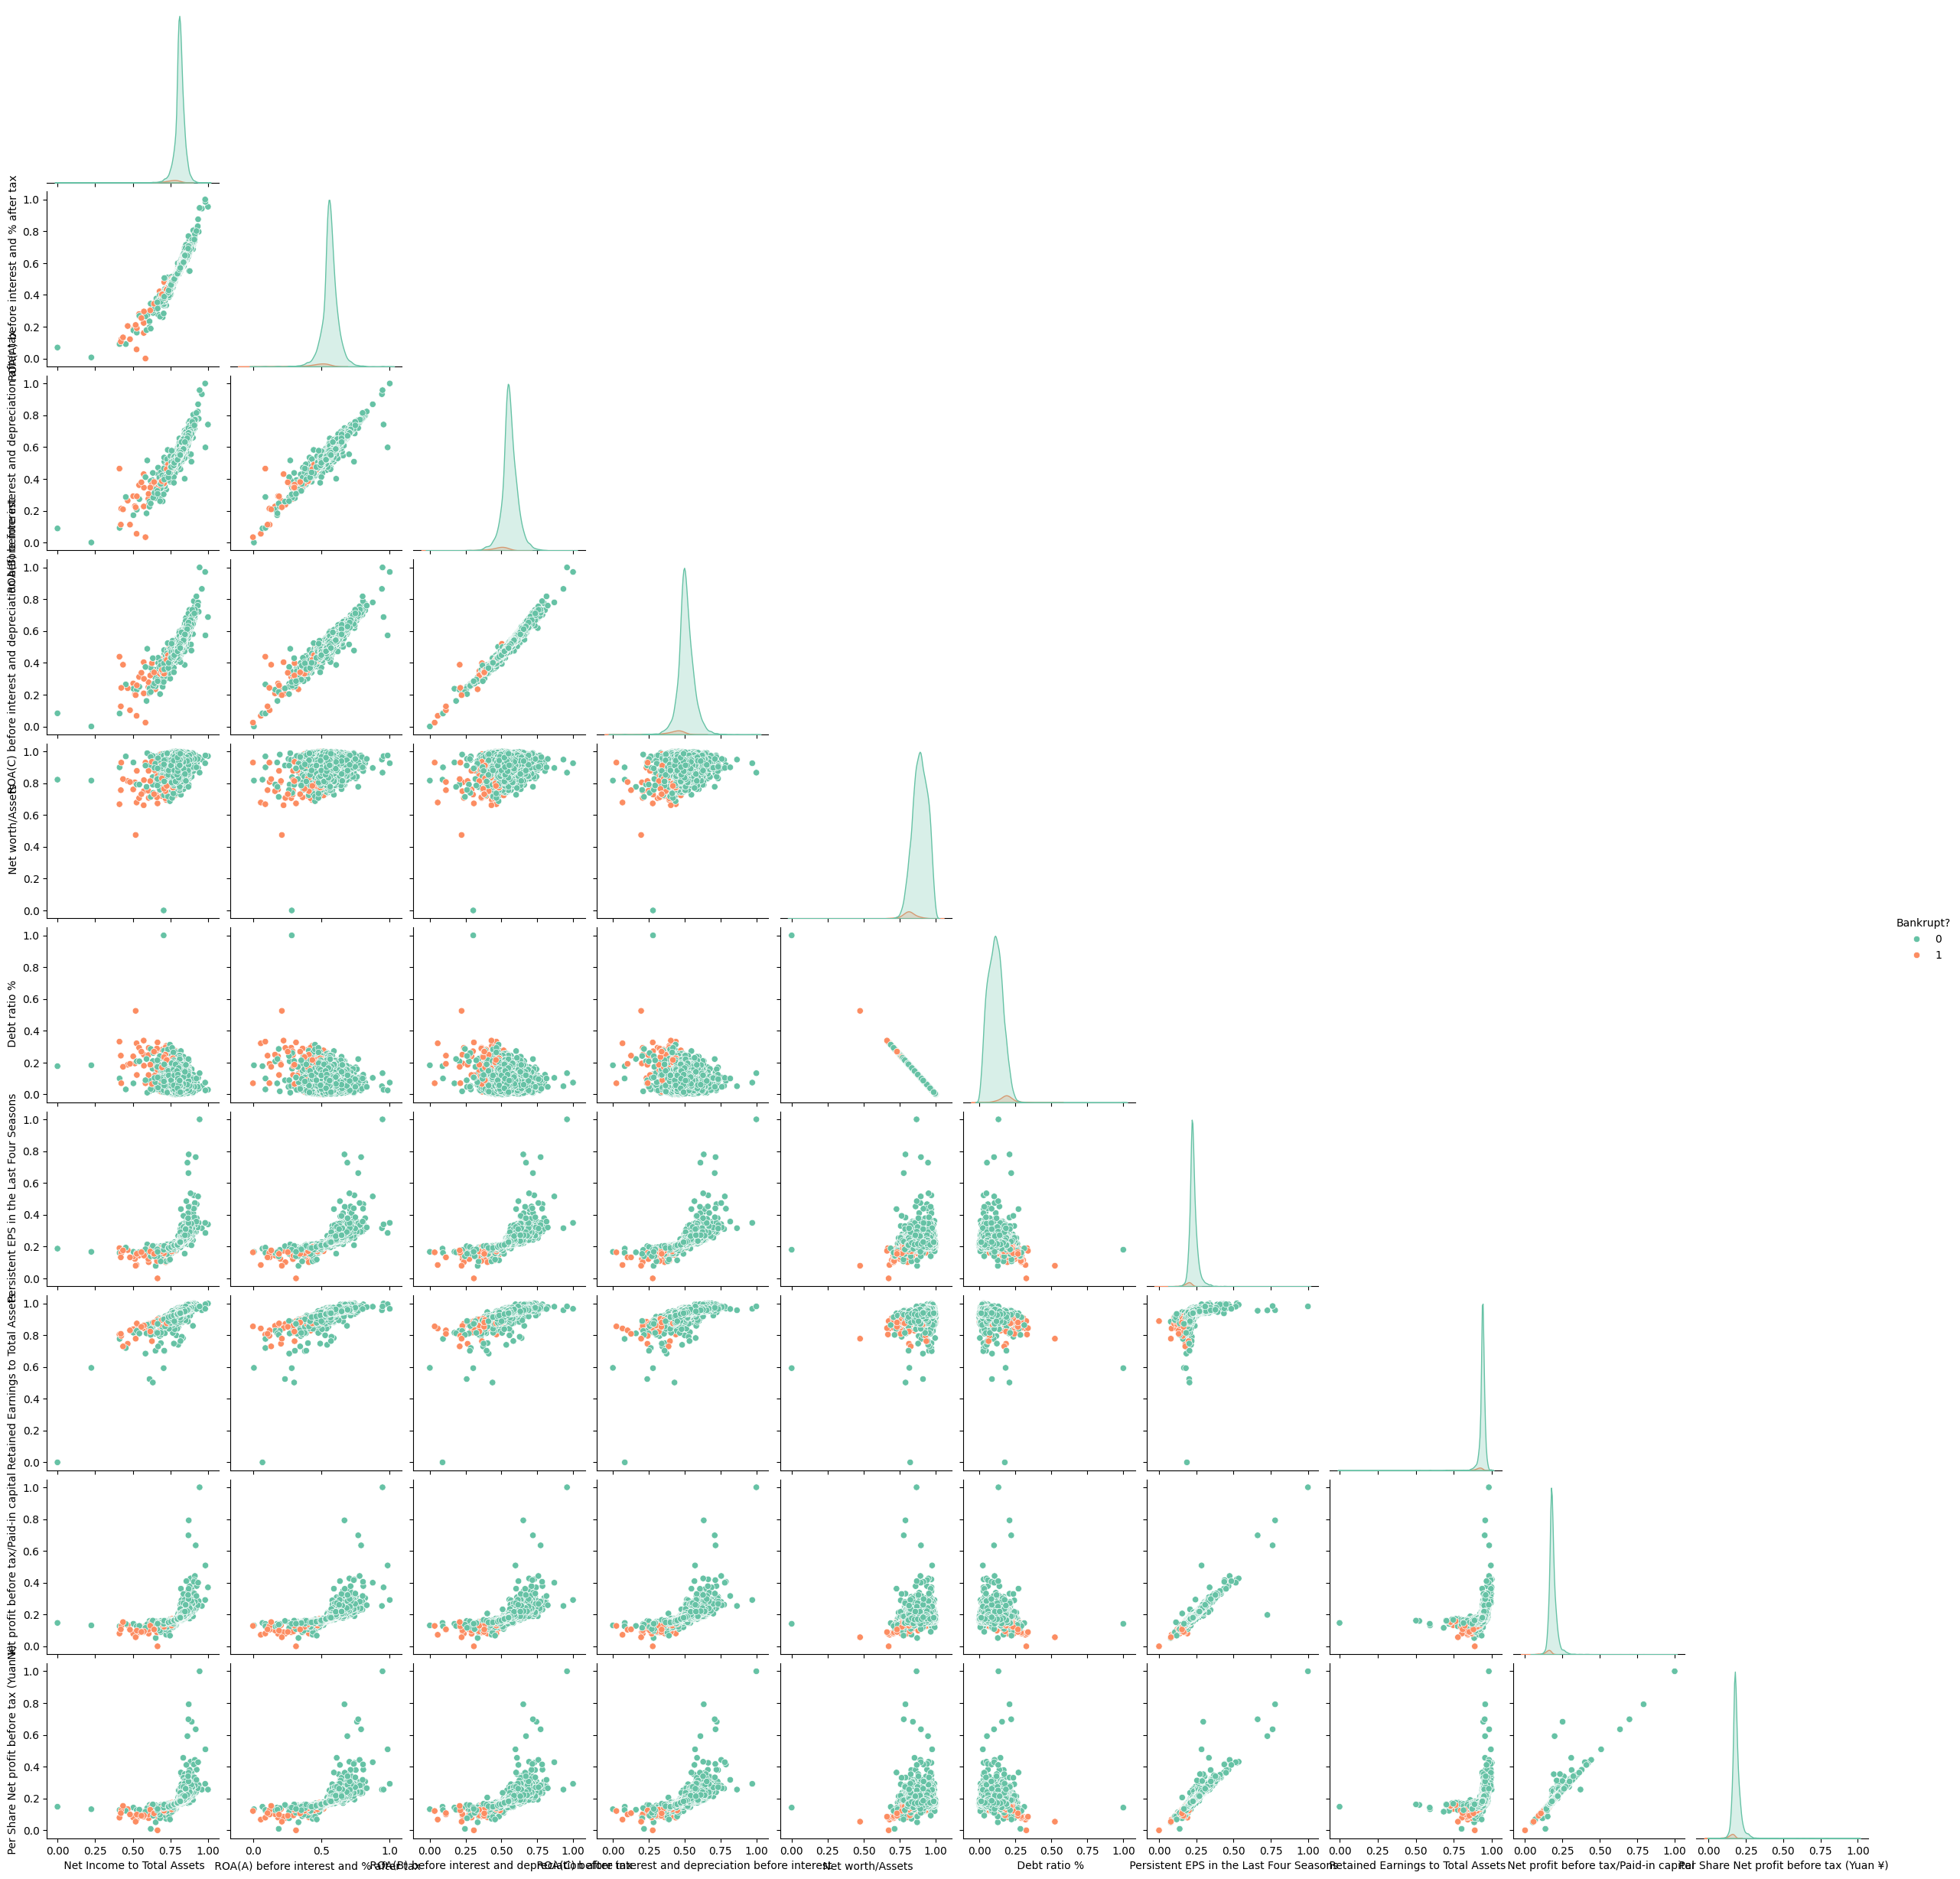

In [10]:
sns.pairplot(
    data[top_features],
    hue=target_col,
    palette='Set2',
    kind='scatter',
    diag_kind='kde',
    corner=True,
    # plot_kws={'alpha': 0.6, 's': 30},
    # diag_kws={'fill': True, 'alpha': 0.4}
)

plt.show()

In [12]:
top_features

Index(['Bankrupt?', ' Net Income to Total Assets',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' ROA(C) before interest and depreciation before interest',
       ' Net worth/Assets', ' Debt ratio %',
       ' Persistent EPS in the Last Four Seasons',
       ' Retained Earnings to Total Assets',
       ' Net profit before tax/Paid-in capital',
       ' Per Share Net profit before tax (Yuan ¥)'],
      dtype='object')

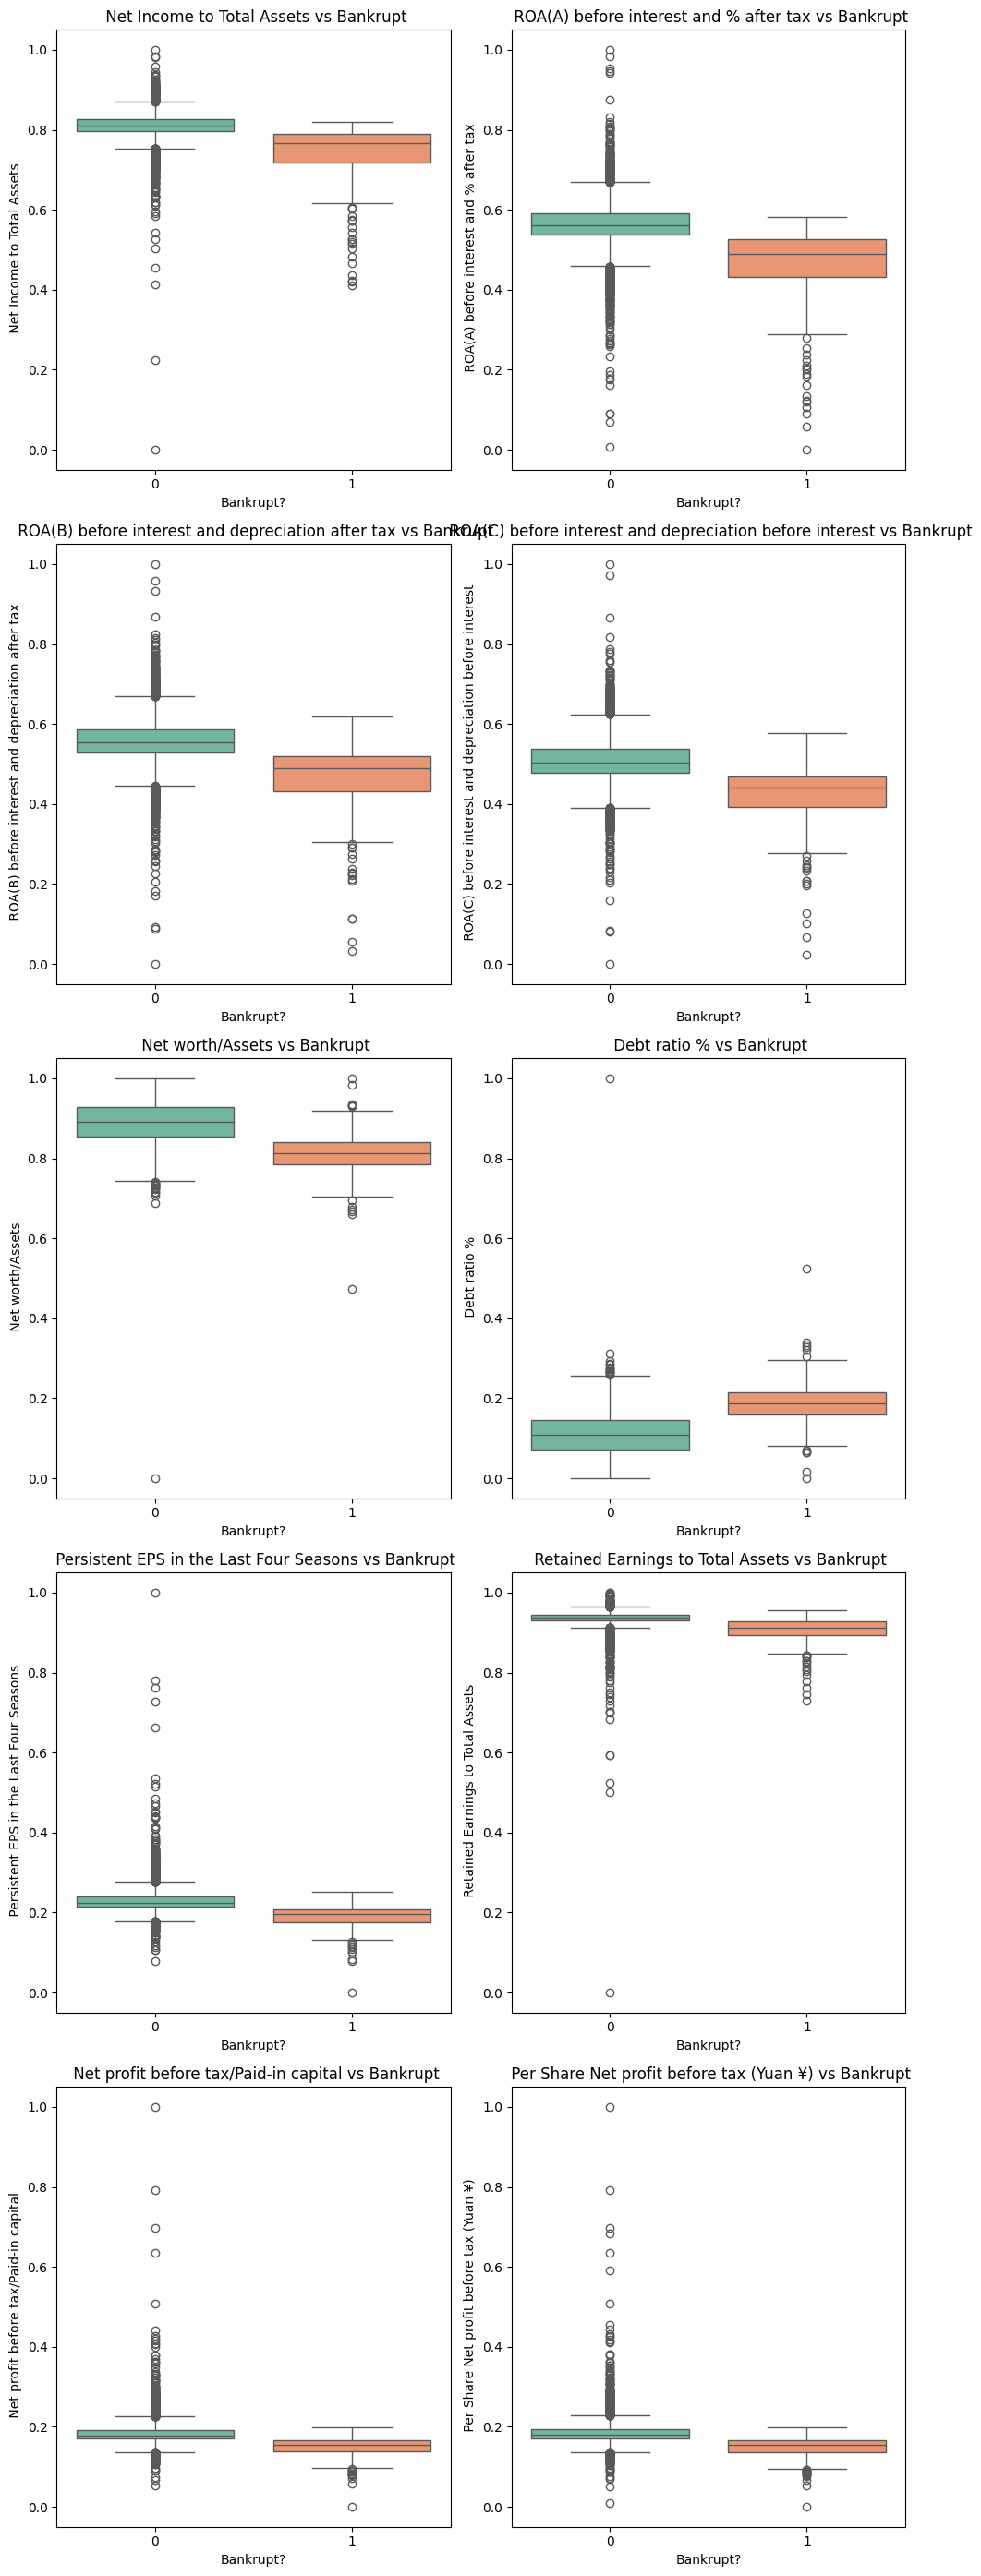

In [16]:
fitur_top = [
    ' Net Income to Total Assets',
    ' ROA(A) before interest and % after tax',
    ' ROA(B) before interest and depreciation after tax',
    ' ROA(C) before interest and depreciation before interest',
    ' Net worth/Assets', ' Debt ratio %',
    ' Persistent EPS in the Last Four Seasons',
    ' Retained Earnings to Total Assets',
    ' Net profit before tax/Paid-in capital',
    ' Per Share Net profit before tax (Yuan ¥)'
    ]

plt.figure(figsize=(10, 28))
for i, col in enumerate(fitur_top):
  plt.subplot(5, 2, i + 1)
  sns.boxplot(data=data, x="Bankrupt?", y=col, hue="Bankrupt?", palette="Set2", legend=False)
  plt.title(f"{col} vs Bankrupt")
plt.tight_layout()
plt.show()

In [18]:
data.nunique()[data.nunique() == 1]

,0
Net Income Flag,1


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [ ]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

In [ ]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.

In [21]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = data.drop(columns=['Bankrupt?', ' Net Income Flag'])
y = data['Bankrupt?']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Ukuran x_train sebelum oversampling: {X_train.shape}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"Ukuran x_train setelah oversampling: {X_train_resampled.shape}")

Ukuran x_train sebelum oversampling: (5455, 94)
Ukuran x_train setelah oversampling: (10558, 94)


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [22]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.

clf_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini.fit(X_train_resampled, y_train_resampled)

DecisionTreeClassifier(random_state=42)

In [23]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_train_pred_gini = clf_gini.predict(X_train_resampled)
y_pred_gini = clf_gini.predict(X_test)

## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [24]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.

clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy.fit(X_train_resampled, y_train_resampled)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [25]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_train_pred_entropy = clf_entropy.predict(X_train_resampled)
y_pred_entropy = clf_entropy.predict(X_test)

## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [38]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).

max_depths = list(range(1, 20)) + [None]

train_accuracies = []
test_accuracies = []

best_criterion = 'entropy'

In [39]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

for depth in max_depths:
    clf = DecisionTreeClassifier(criterion=best_criterion, max_depth=depth, random_state=42)
    clf.fit(X_train_resampled, y_train_resampled)

    y_train_pred = clf.predict(X_train_resampled)
    y_test_pred = clf.predict(X_test)

    train_accuracies.append(accuracy_score(y_train_resampled, y_train_pred))
    test_accuracies.append(accuracy_score(y_test, y_test_pred))

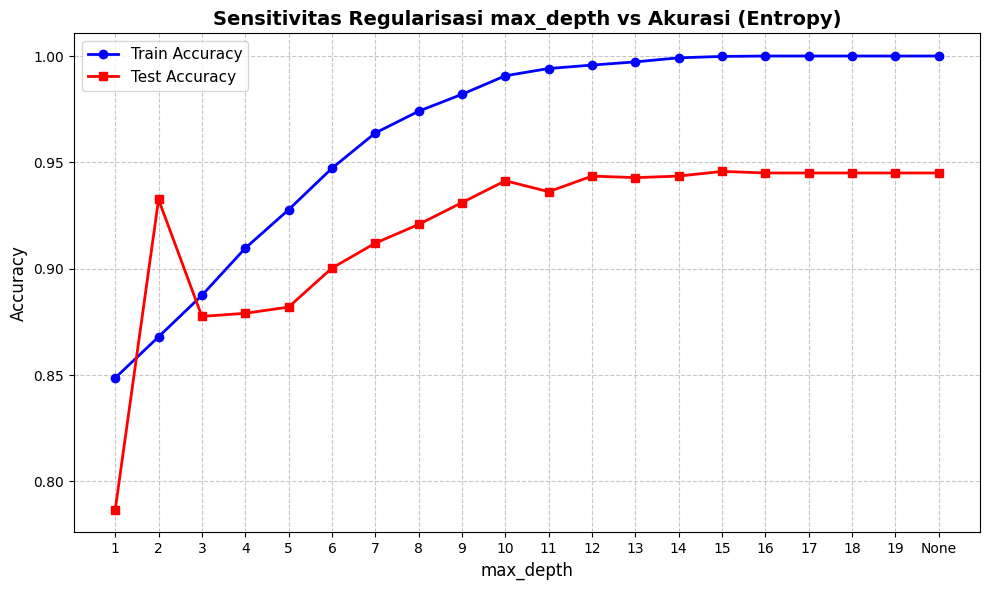

In [40]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

plt.figure(figsize=(10, 6))

depth_labels = [str(d) for d in max_depths]

plt.plot(depth_labels, train_accuracies, marker='o', label='Train Accuracy', color='blue', linewidth=2)
plt.plot(depth_labels, test_accuracies, marker='s', label='Test Accuracy', color='red', linewidth=2)

plt.title(f'Sensitivitas Regularisasi max_depth vs Akurasi ({best_criterion.capitalize()})', fontsize=14, fontweight='bold')
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [29]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

metrics_data = {
    'Model': ['DT Gini', 'DT Entropy'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_gini),
        accuracy_score(y_test, y_pred_entropy)
    ],
    'Precision': [
        precision_score(y_test, y_pred_gini, pos_label=1),
        precision_score(y_test, y_pred_entropy, pos_label=1)
    ],
    'Recall': [
        recall_score(y_test, y_pred_gini, pos_label=1),
        recall_score(y_test, y_pred_entropy, pos_label=1)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_gini, pos_label=1),
        f1_score(y_test, y_pred_entropy, pos_label=1)
    ]
}

df_comparison = pd.DataFrame(metrics_data)
df_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,DT Gini,0.928152,0.235294,0.545455,0.328767
1,DT Entropy,0.945015,0.293333,0.500000,0.369748


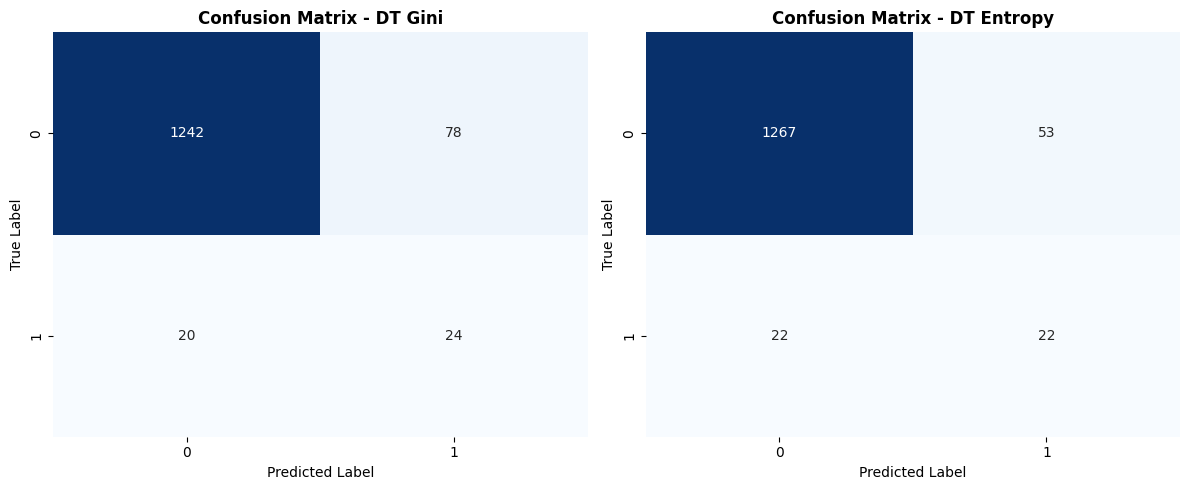

In [31]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = [
    ('DT Gini', y_pred_gini, axes[0]),
    ('DT Entropy', y_pred_entropy, axes[1])
]

for title, y_pred, ax in models:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'Confusion Matrix - {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

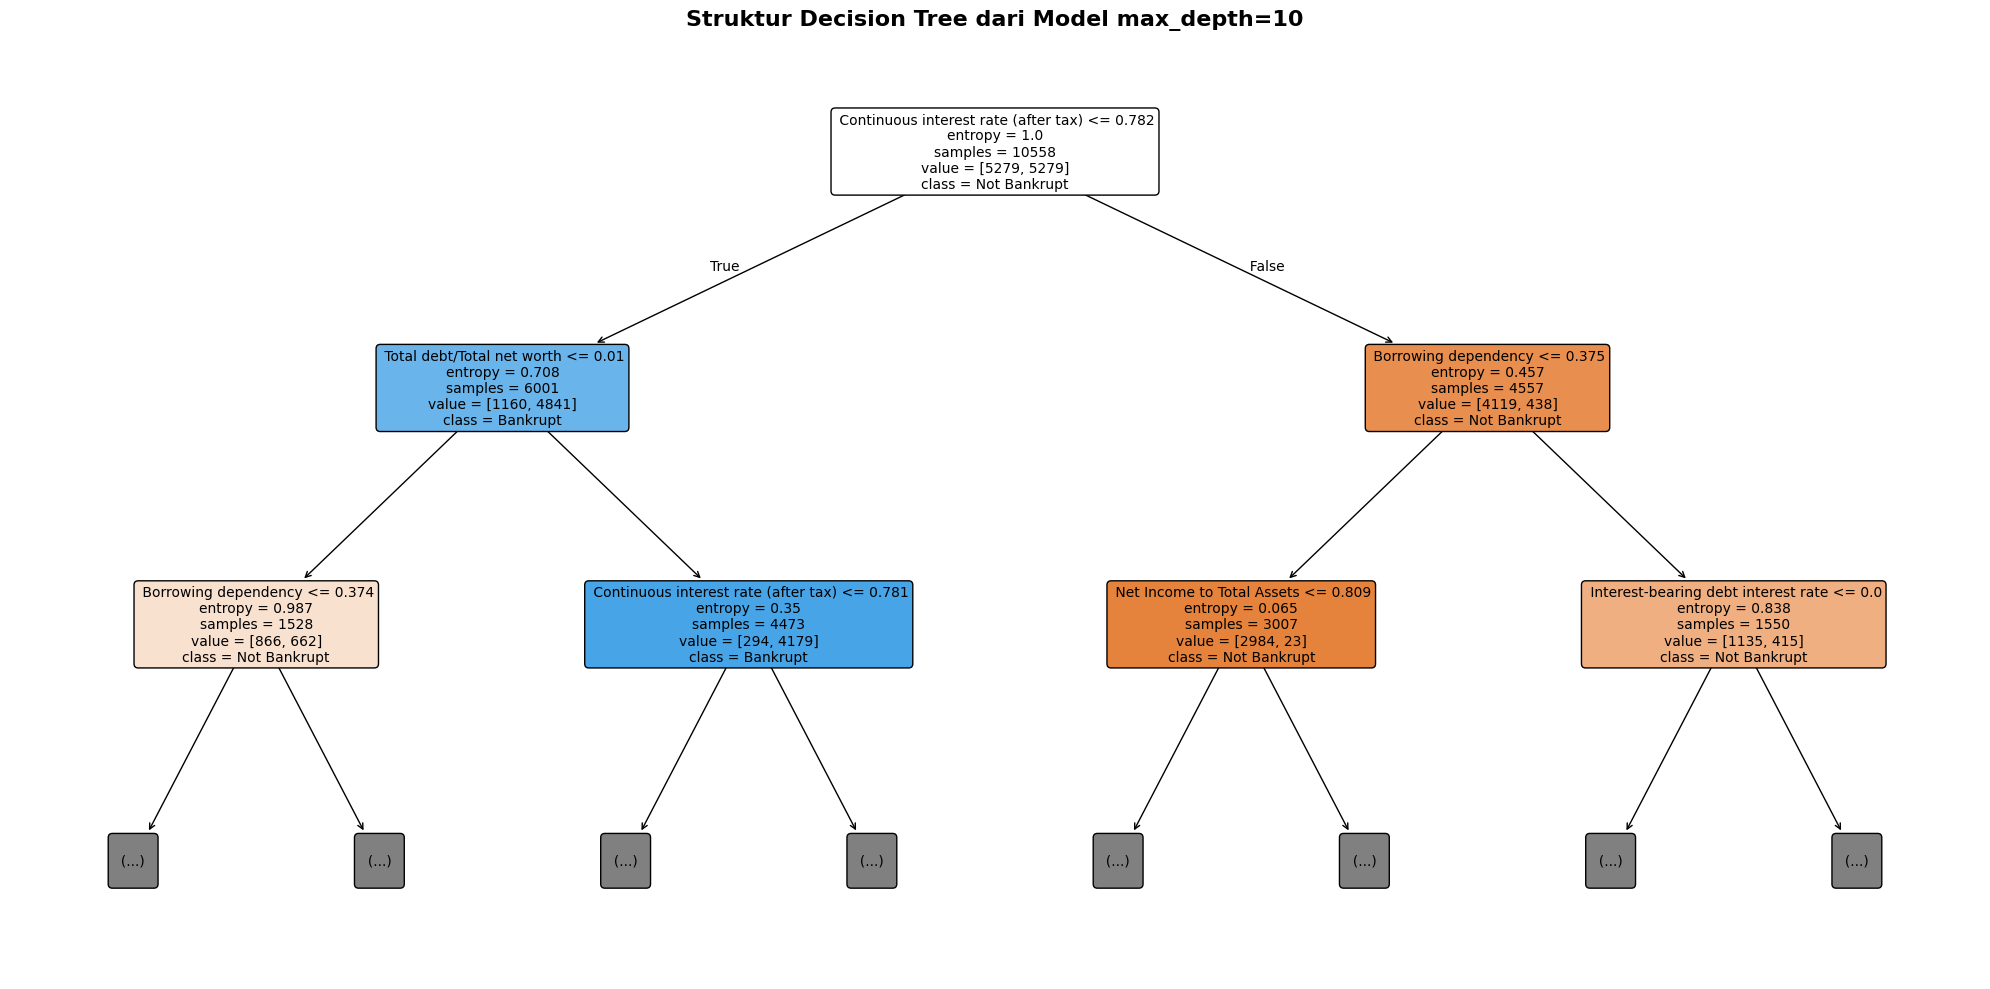

In [43]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.

best_max_depth = 10
clf_best = DecisionTreeClassifier(criterion='entropy', max_depth=best_max_depth, random_state=42)
clf_best.fit(X_train_resampled, y_train_resampled)

plt.figure(figsize=(20, 10))

plot_tree(
    clf_best,
    max_depth=2,
    feature_names=X.columns,
    class_names=['Not Bankrupt', 'Bankrupt'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title(f"Struktur Decision Tree dari Model max_depth={best_max_depth}", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

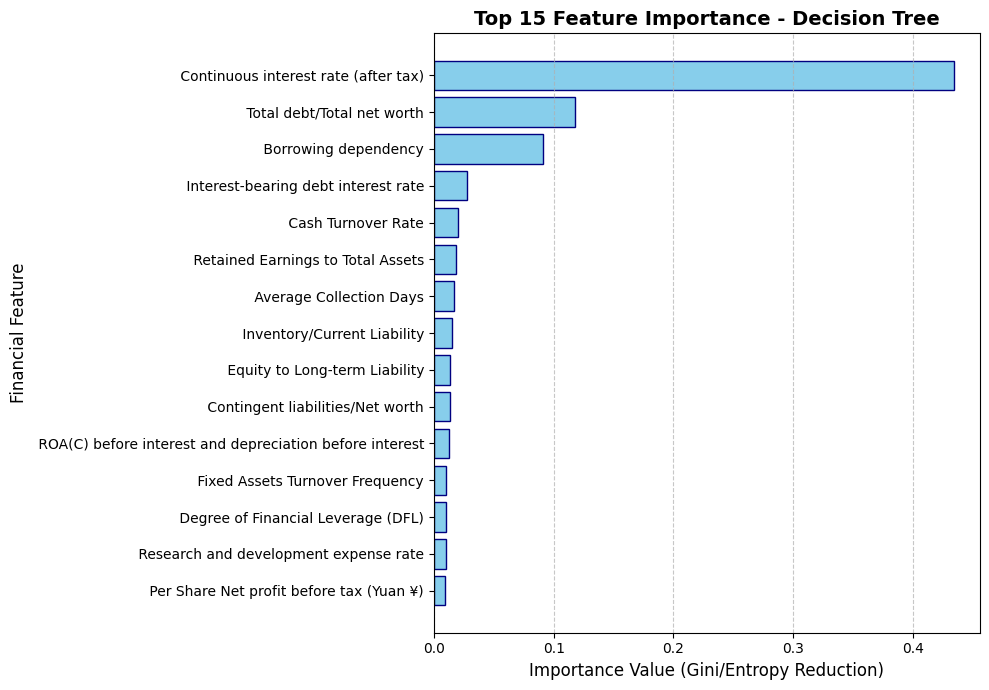

In [44]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.

importances = clf_best.feature_importances_
feature_names = X.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

top_n = 15
df_top_importance = df_importance.tail(top_n)

plt.figure(figsize=(10, 7))
plt.barh(df_top_importance['Feature'], df_top_importance['Importance'], color='skyblue', edgecolor='navy')

plt.title(f'Top {top_n} Feature Importance - Decision Tree', fontsize=14, fontweight='bold')
plt.xlabel('Importance Value (Gini/Entropy Reduction)', fontsize=12)
plt.ylabel('Financial Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 5. Analisis

## 1. Perbandingan Performa Gini dan Entropy
### Secara keseluruhan akurasi model DT Entropy sedikit lebih unggul (94.50%) dibanding DT Gini (92.82%). Namun, jika kita menelaah confusion matrix dan metrik evaluasi kelas positif (Bankrupt = 1), DT Gini menghasilkan recall yang lebih tinggi (54.55% vs 50.00%), di mana gini berhasil mendeteksi 24 dari 44 kasus perusahaan bangkrut. Di sisi lain, DT Entropy menghasilkan precision (29.33% vs 23.53%) dan F1-Score (0.3697 vs 0.3288) yang lebih tinggi, karena berhasil menekan jumlah False Positive (hanya 53 kesalahan menebak bangkrut dibanding Gini yang sebanyak 78).

## 2. Eksperimen Regularisasi (max_depth) dan Gejala Overfitting
### Berdasarkan grafik sensitivitas max_depth vs Akurasi, model mulai menunjukkan gejala overfitting ketika mencapai max_depth = 15 ke atas. Hal ini ditunjukkan oleh akurasi training yang terus merambat naik hingga menyentuh nilai sempurna 1.00 (100%) pada kedalaman 15 ke atas, akurasi test yang berhenti tumbuh dan mengalami stagnasi mendatar di angka 94.5%, serta muncul gap sebesar 5.5% antara kurva train dan test yang menandakan model mulai menghafal noise sampel data training. Namun, terdapat anomali di mana akurasi test melonjak tajam pada max_depth = 2 (93.3%). Ini merupakan kondisi underfitting di mana pohon hanya membuat 2 keputusan dan memprediksi mayoritas data sebagai kelas 0 sehingga akurasi keseluruhannya tampak tinggi. Oleh karena itu, nilai kedalaman ideal berada di max_depth = 10 hingga 12, di mana akurasi test mencapai puncak optimal (94.1% - 94.4%) dengan akurasi train yang belum menyentuh 100% (99%), sehingga generalization gap-nya lebih terkendali.

## 3. Fitur Paling Berpengaruh (Feature Importance)
### Berdasarkan grafik Top 15 Feature Importance, prediksi kebangkrutan perusahaan didominasi oleh 3 fitur yaitu Continuous interest rate (after tax), Total debt/Total net worth, dan Borrowing dependency. Model Decision Tree menangkap bahwa faktor risiko hutang dan beban suku bunga/pinjaman (leverage & debt-burden ratio) jauh lebih menentukan risiko kebangkrutan suatu perusahaan dibandingkan sekadar rasio profitabilitas murni (ROA atau EPS).

# 6. Kesimpulan dan Saran

### Eksperimen klasifikasi kebangkrutan perusahaan menggunakan Decision Tree menunjukkan bahwa model berbasis Entropy menghasilkan akurasi, precision, dan F1-score yang sedikit lebih unggul dibandingkan Gini Impurity, meskipun kriteria Gini mencatatkan tingkat recall yang lebih tinggi dalam mendeteksi perusahaan bangkrut. Pengujian regularisasi membuktikan bahwa pembatasan max_depth sangat efektif dalam menekan risiko overfitting di mana model mulai menunjukkan gejala menghafal data pada max_depth >= 15 dengan train accuracy mencapai 100% sementara test accuracy stagnan di angka 94.5%. Selain itu, analisis feature importance menegaskan bahwa faktor beban keuangan dan risiko utang—khususnya Continuous interest rate (after tax) dan Total debt/Total net worth menjadi indikator paling mendominasi dalam memprediksi kebangkrutan dibandingkan rasio profitabilitas murni.

### Untuk pengembangan eksperimen selanjutnya, pemilihan dataset yang lebih baik dapat membantu untuk lebih memahami model yang dipelajari. Eksplorasi hyperparameter juga sebaiknya diperluas tidak hanya terbatas pada max_depth, tetapi juga membandingkan kombinasi parameter lain seperti min_samples_split, min_samples_leaf, dan max_leaf_nodes. Terakhir, alih-alih hanya mengandalkan pre-pruning, akan lebih menarik jika dilakukan pula percobaan post-pruning untuk menemukan struktur pohon yang lebih optimal, ringkas, dan memiliki daya generalisasi yang lebih kuat terhadap data baru.